In [1]:
import torch
from torch import nn

In [ ]:
# Getting data

import requests
import zipfile
from pathlib import Path

data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"{image_path} directory already exists...skipping download")
else:
    print(f"{image_path} does not exist, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
# Download data
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("Downloading pizza, steak, sushi data...")
    f.write(request.content)
    
# Unzip data
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    print("Unzipping pizza, steak and sushi data...")
    zip_ref.extractall(image_path)



data\pizza_steak_sushi directory already exists...skipping download


# Data preparation and data exploration

In [4]:
import os
def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [5]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'.


In [2]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

NameError: name 'image_path' is not defined

Random image path: data\pizza_steak_sushi\train\pizza\765799.jpg
Image class: pizza
Image height: 512
Image width: 511


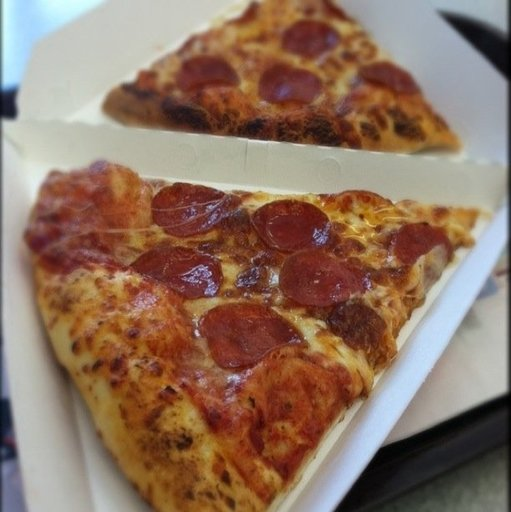

In [7]:
# Visualizing an image

import random
from PIL import Image

#random.seed(42)

# Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

# Pick a random image path
random_image_path = random.choice(image_path_list)
#print(random_image_path)

# Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem
#print(image_class)

# Open image
img = Image.open(random_image_path)

# Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(510.5), np.float64(511.5), np.float64(-0.5))

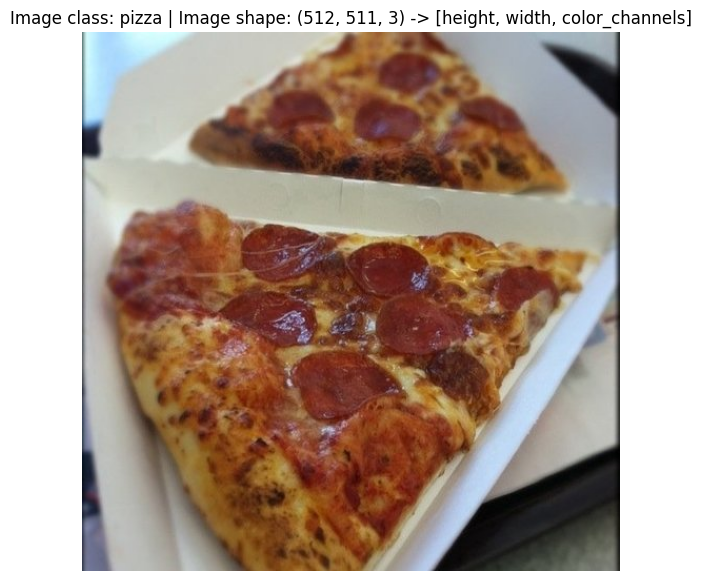

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False)


# Transforming data

In [9]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Write a transform for image
data_transform = transforms.Compose([
    # Resize our images to 64x64
    transforms.Resize(size=(64, 64)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    # Turn the image into a torch.Tensor
    transforms.ToTensor()
])

In [10]:
data_transform(img)

tensor([[[0.4706, 0.6431, 0.6549,  ..., 0.6784, 0.7451, 0.7216],
         [0.4627, 0.6353, 0.6392,  ..., 0.6745, 0.7373, 0.7137],
         [0.4549, 0.6118, 0.5725,  ..., 0.6824, 0.7333, 0.7137],
         ...,
         [0.3255, 0.4196, 0.4039,  ..., 0.4706, 0.4235, 0.3882],
         [0.3490, 0.4627, 0.4471,  ..., 0.4392, 0.4235, 0.3882],
         [0.3608, 0.4745, 0.4549,  ..., 0.4314, 0.4275, 0.3882]],

        [[0.5059, 0.6863, 0.7059,  ..., 0.8667, 0.9294, 0.8667],
         [0.4941, 0.6745, 0.6941,  ..., 0.8667, 0.9255, 0.8667],
         [0.4863, 0.6549, 0.6235,  ..., 0.8706, 0.9294, 0.8627],
         ...,
         [0.3294, 0.4275, 0.4196,  ..., 0.4745, 0.4392, 0.4000],
         [0.3529, 0.4745, 0.4588,  ..., 0.4471, 0.4392, 0.4039],
         [0.3647, 0.4863, 0.4667,  ..., 0.4392, 0.4471, 0.4118]],

        [[0.5137, 0.7098, 0.7373,  ..., 0.9961, 0.9961, 0.8784],
         [0.5098, 0.7059, 0.7255,  ..., 0.9961, 0.9922, 0.8745],
         [0.5098, 0.6902, 0.6510,  ..., 0.9922, 0.9922, 0.

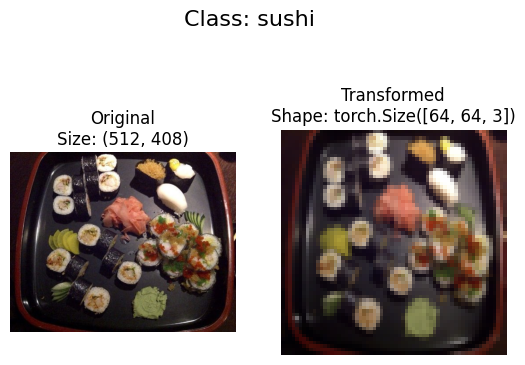

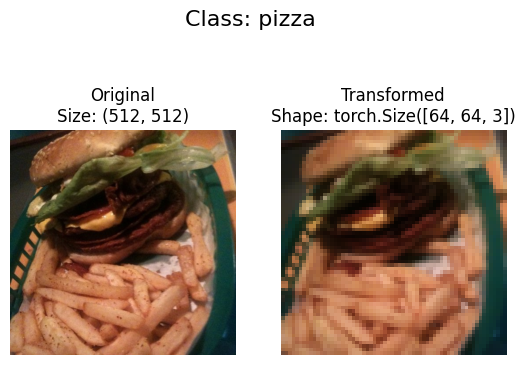

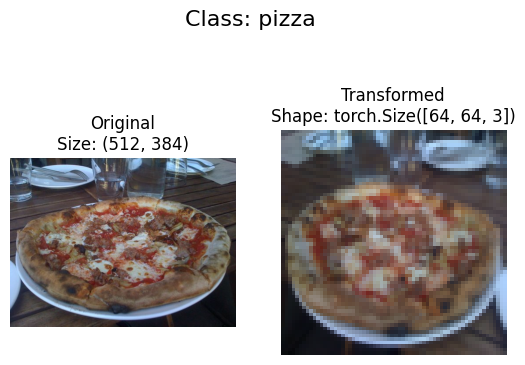

In [12]:
def plot_transformed_images(image_paths: list, transform, n=3, seed=None):
    """Selects random images from a path of images and loads/transforms them then 
    plots the original vs the transformed version."""
    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize: {f.size}")
            ax[0].axis(False)
            
            # Transfrom and plot target image
            transformed_image = transform(f).permute(1, 2, 0) # (C, H, W) -> (H, W, C)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
            ax[1].axis("off") 
            
            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_paths=image_path_list, transform=data_transform, n=3, seed=42)


In [1]:
# Use ImageFolder to create dataset(s)

from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir, transform=data_transform, target_transform=None)
test_data = datasets.ImageFolder(root=test_dir, transform=data_transform)

train_data, test_data


NameError: name 'train_dir' is not defined